<a href="https://colab.research.google.com/github/Albedofan69420/FASHION-MNIST/blob/main/INTENTO_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integrantes:


*   
*   
*
*
*
*
---

---


# **Introducción:**


En el presente trabajo se aplicarán los fundamentos de Deep Learning mediante la implementación de una red neuroal artificial de tipo *Multilayer Perceptron (MLP)* para resolver un problema de clasificación de imágenes. Para ello, se utiliza el data set **Fashion-MNIST**, el cual contiene imágenes en escala de grises de 28x28 píxeles correspondientes a distintas categorías de prendas de vestir, tales como camisetas, pantalones, zapatillas, entre otros.



**Objetivo principal:**

Desarrollar un modelo capaz de aprender patrones a partir de los datos y clasificar correctamente nuevas imágenes. Para lograrlo, se realiza un proceso completo que abarca desde la carga y preprocesamiento de los datos hasta la evaluación del modelo utilziando diversas métricas de desempeño.

En una primera etapa, se preparan los datos para su uso en redes neuroales, transformando las imágenes a vectores y normalizando sus valores para mejorar la eficiencia del entrenamiento. Posteriormente, se construye una red neuronal multicapa, definiendo su arquitectura, funciones de activación y función de pérdida.

A continuación, se entrenará el modelo variando distintos hiperparámetros claves, tales como el número de épocas, tamaño de batch y optimizadores. Se realizará una comparación entre distintos algoritmos de optimización, incluyendo *SGD, Adam, RMSprop*, así como variantes como *Momentum y Nesterov*, con el fin de identificar cuál ofrece un mejor desempeño.

Además, se incorporarán técnicas de regularización como *Dropout y Early Stopping*, con el objetivo de reducir el sobreajuste(*overfitting*) y mejorar la capacidad de generalización del modelo.

Finalmente, el desempeño del modelo será evaluado mediante métricas como *accuracy, precision, recall y F1-score*, permitiendo analizar de manera integral la calidad de las predicciones. A partir de estos resultados, se jusatificarán las decisiones tomadas durante el desarrollo y se seleccionará la mejor configuración del modelo, mostrando ejemplos visuales de cómo responde el mejor modelo obtenido.



---
---


# **PARTE 1: Carga de Datos.**

In [ ]:
# import de librerias
from tensorflow import keras
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cargar dataset Fashion-MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Mostrar dimensiones
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


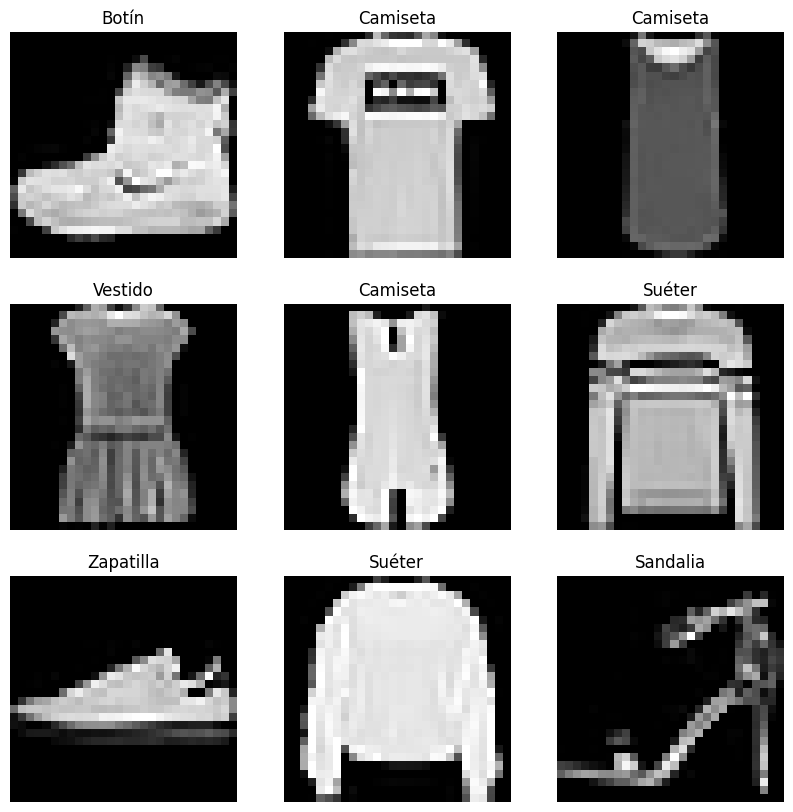

In [ ]:
# Nombres de clases
clases = ['Camiseta', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
          'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

# Mostrar ejemplos
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(clases[y_train[i]])
    plt.axis('off')
plt.show()

Se utilizó el dataset Fashion-MNIST disponible en Keras, el cual contiene imágenes en escala de grises de 28x28 píxeles correspondientes a distintas categorías de prendas de vestir.

El conjunto de datos está dividido en 60.000 imágenes para entrenamiento y 10.000 para prueba. Cada imagen está etiquetada en una de las 10 clases disponibles, como camisetas, pantalones, zapatos, entre otros.

Se visualizaron algunos ejemplos del dataset para comprender la estructura de los datos y las clases asociadas.



---
---


# **PARTE 2: Preprocesamiento de Datos.**

In [ ]:
# Normalizar los datos (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Aplanar las imágenes (28x28 → 784)
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

Y_train = y_train
Y_test = y_test

# Verificamos dimensiones
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

X_train: (60000, 784)
Y_train: (60000,)


Para preparar los datos para el entrenamiento de la red neuronal, se realizaron varias transformaciones.

Primero, se normalizaron los valores de los píxeles dividiéndolos por 255, con el objetivo de llevarlos a un rango entre 0 y 1. Esto mejora la estabilidad del entrenamiento y permite una mejor convergencia del modelo.

Luego, las imágenes de 28x28 píxeles fueron transformadas a vectores unidimensionales de 784 elementos, ya que las redes MLP requieren entradas en formato vectorial.

Las etiquetas se representaron como números enteros del 0 al 9, donde cada número corresponde a una clase.
Para que el modelo pueda trabajar con este formato, se utilizó la función de pérdida sparse categorical crossentropy, que permite entrenar directamente con etiquetas numéricas sin necesidad de codificación adicional.



---

---

# **PARTE 3: Modelo MLP.**

In [ ]:
# setamos los seed para números random:

np.random.seed(30)
tf.random.set_seed(30)

# Definimos las dimensiones de entrada y salida
N = X_train.shape[1]  # Dimensiones de entrada (784 píxeles)
C = 10 # Número de clases de salida (10 clases)

# Creación de la red:

h1 = 512
h2 = 256

def crear_modelo():
    model = keras.Sequential([
        keras.layers.Dense(h1, input_dim=N,  activation='relu'),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:
modelA = crear_modelo()
modelA.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601,610 (2.29 MB)

 Trainable params: 601,610 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

El modelo implementado corresponde a una red neuronal multicapa (MLP) compuesta por tres capas ocultas con 512, 256 y 256 neuronas respectivamente, y una capa de salida de 10 neuronas.

El modelo presenta un total de 601.610 parámetros entrenables, lo que indica una alta capacidad de aprendizaje. Esta gran cantidad de parámetros permite al modelo capturar patrones complejos presentes en las imágenes del dataset.

Sin embargo, esta alta capacidad también implica un mayor riesgo de sobreajuste, ya que el modelo puede llegar a memorizar los datos de entrenamiento en lugar de generalizar correctamente.

Por esta razón, este modelo será utilizado como base para posteriormente aplicar técnicas de regularización que permitan mejorar su desempeño en datos no vistos.


---
---


# **PARTE 4: Entrenamiento y Visualización.**

# **4.1: Entrenamiento A:**

Se decidió entrenar el *modelA* con **30 épocas** y un **batch size de 32**, debido a que es una configuración estándar para tener una primera exploración para observar el comportamiento del modelo sin inucrrir en tiempos de entrenamiento excesivos.

In [ ]:
# ===== ENTRENAMIENTO A =====
np.random.seed(30)
tf.random.set_seed(30)

modelA = crear_modelo()

historyA = modelA.fit(
    X_train, Y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8206 - loss: 0.4945 - val_accuracy: 0.8522 - val_loss: 0.4011
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8623 - loss: 0.3736 - val_accuracy: 0.8658 - val_loss: 0.3632
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.8753 - loss: 0.3341 - val_accuracy: 0.8732 - val_loss: 0.3556
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8848 - loss: 0.3060 - val_accuracy: 0.8733 - val_loss: 0.3524
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8934 - loss: 0.2853 - val_accuracy: 0.8830 - val_loss: 0.3306
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8977 - loss: 0.2687 - val_accuracy: 0.8863 - val_loss: 0.3317
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9038 - loss: 0.2539 - val_accuracy: 0.8889 - val_loss: 0.3346
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9084 -

In [ ]:
# Resultados modelA:

print(f"Train accuracy \u2248 {historyA.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {historyA.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 95.4%
Val accuracy ≈ 88.9%


# **4.2: Visualización entrenamiento A:**

# Gráfico de Loss y Accuracy:

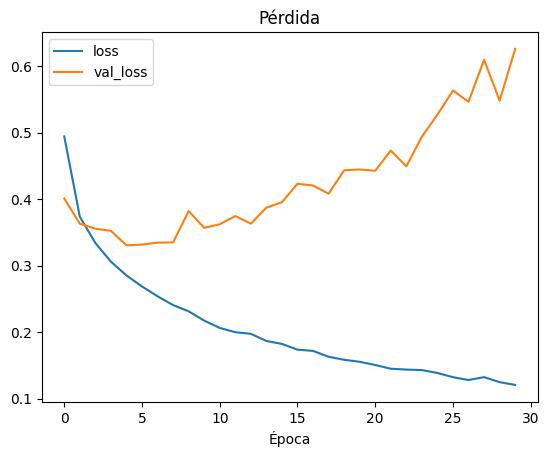

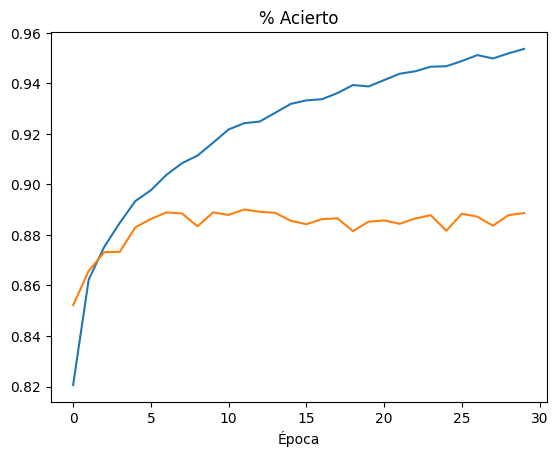

In [ ]:
# Loss
plt.plot(historyA.history['loss'], label='loss')
plt.plot(historyA.history['val_loss'], label='val_loss')
plt.title('Pérdida')
plt.xlabel('Época')
plt.legend()
plt.show()

# Accuracy
plt.plot(historyA.history['accuracy'], label='accuracy')
plt.plot(historyA.history['val_accuracy'], label='val_accuracy')
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

***Pérdida***

*   La **pérdida de entrenamiento** disminuye de forma constante a lo largo de las épocas, indicando que el modelo está aprendiendo correctamente los patrones de datos de entrenamiento.

*   Por otro lado, la **pérdida de validación** disminuye inicialmente, pero luego comienza a aumentar progresivamente, lo que es una señal clara de **sobreajuste**.



***Acierto***

*   El **accuracy de entrenamiento** aumentaa de forma sostenida, alcanzando valores cercanos al 95%. Esto indica que el modelo se ajusta muy bien a los datos que ha visto.
*   El **accuracy de validación** mejora al inicio pero luego se estanca e inluso presenta pequeñas fluctuaciones. Este becha creciente entrenamiento y validación refuerza la presencia de **overfitting**.



---



---



# **4.3: Entrenamiento B:**

Ante la evidencia del entrenamiento anterior, se tomó la decisión de aumentar los hiperparámetros por **50 épocas**  y un **batch size de 128**, lo que permite analizar cómo del modelo se comporta bajo una configuración más intensiva.

In [ ]:
# ===== ENTRENAMIENTO B =====
np.random.seed(30)
tf.random.set_seed(30)

modelB = crear_modelo()

historyB = modelB.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8158 - loss: 0.5108 - val_accuracy: 0.8507 - val_loss: 0.3998
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8673 - loss: 0.3612 - val_accuracy: 0.8712 - val_loss: 0.3472
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8797 - loss: 0.3227 - val_accuracy: 0.8810 - val_loss: 0.3271
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8905 - loss: 0.2976 - val_accuracy: 0.8733 - val_loss: 0.3400
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8980 - loss: 0.2753 - val_accuracy: 0.8827 - val_loss: 0.3229
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9040 - loss: 0.2561 - val_accuracy: 0.8835 - val_loss: 0.3315
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9078 - loss: 0.2443 - val_accuracy: 0.8798 - val_loss: 0.3326
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9108 - loss: 0.2359 - val_accu

In [ ]:
# Resultados modelB:

print(f"Train accuracy \u2248 {historyB.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {historyB.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 97.5%
Val accuracy ≈ 87.9%


# **4.4: Visualización entrenamiento B:**

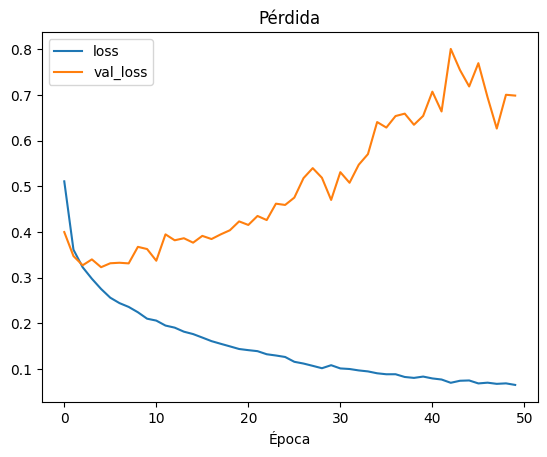

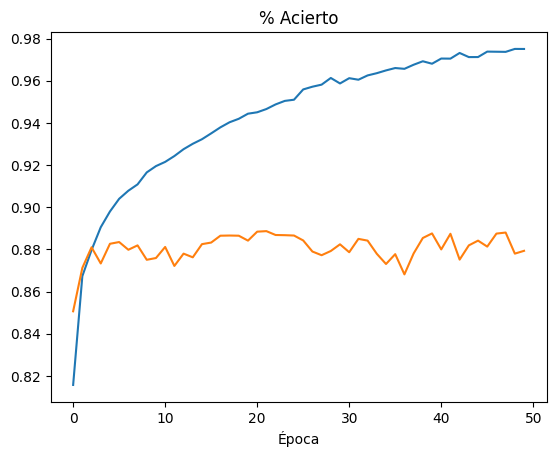

In [ ]:
# Loss
plt.plot(historyB.history['loss'], label='loss')
plt.plot(historyB.history['val_loss'], label='val_loss')
plt.title('Pérdida')
plt.xlabel('Época')
plt.legend()
plt.show()

# Accuracy
plt.plot(historyB.history['accuracy'], label='accuracy')
plt.plot(historyB.history['val_accuracy'], label='val_accuracy')
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

***Pérdida***
* La **pérdida de entrenamiento** disminuye de forma continua, alcanzando valores muy bajos, lo que indica que el modelo está aprendiendo bien.
* La **pérdida de validación** disminuye levemente al inicio. Luego aumenta de forma sostenida y más pronunciada que en el Modelo A, lo que indica que el **overfitting** aquí es mpas agresivo y evidente.


***Acierto***
* El **accuracy de entrenamiento** sigue aumentando hasta un 97% o 98%, lo que demuestra que el modelo está **memorizando** los datos.
* El **accuracy de validación** no mejora pese al aumento de épocas.




---



---



# **Conclusión:**

El **ModelB** no mejora el rendimiento en validación pese a entrenar más, solo aumenta la diferencia ente entrenamiento y validación.


 Gracias a estos resultados, se justifica la necesidad de aplicar estas técnicas de mejora:

> **Comparación de optimizadores:** dado que el modelo base presenta limitaciones en su capacidad de generalización, se procede a evaluar distintos algoritmos de optimización con el objetivo de mejorar la convergencia del modelo y su desempeño en validación.

> **Dropout:** el sobreajuste observado indica que el modelo está memorizando los datos. Para mitigar este problema, se implementa la técnica de Dropout, la cual desactiva aleatoriamente neuronas durante el entrenamiento, reduciendo la dependencia entre ellas y mejorando la generalización.

> **Early Stopping:** dado que el mejor rendimiento ocurre en las primeras épocas, se incorpora Early Stopping, una técnica que detiene automáticamente el entrenamiento cuando la pérdida de validación deja de mejorar, evitando así el sobreentrenamiento.






---



---



# **PARTE 5: Comparación de optimizadores.**



En esta parte, se evaluarán cómo distintos optimizadores afectan el aprendizaje del modelo MLP.

Se probaran:

- **SGD.**
- **SGD + Momentum.**
- **SGD + Nesterov.**
- **Adam.**
- **RMSprop.**


# **5.1: Creación modelo base para comparación:**

In [ ]:
# Semillas para reproducibilidad
np.random.seed(30)
tf.random.set_seed(30)

# Definición de optimizadores
optimizadores = {
    'SGD': keras.optimizers.SGD(),
    'SGD + Momentum': keras.optimizers.SGD(momentum=0.9),
    'SGD + Nesterov': keras.optimizers.SGD(momentum=0.9, nesterov=True),
    'Adam': keras.optimizers.Adam(),
    'RMSprop': keras.optimizers.RMSprop()
}

#definición del modelo base
def crear_modelo():
    model = keras.Sequential([
        keras.layers.Dense(512, activation='relu', input_dim=784),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# **5.2: Entrenamiento con distintos optimizadores:**

Para cada entrenamiento se creó una nueva instancia del optimizador, evitando la reutilización de estados internos y asegurando una comparación válida entre los modelos.

In [ ]:
histories = {}
resultados = []

optimizadores = {
    'SGD': lambda: keras.optimizers.SGD(),
    'SGD + Momentum': lambda: keras.optimizers.SGD(momentum=0.9),
    'SGD + Nesterov': lambda: keras.optimizers.SGD(momentum=0.9, nesterov=True),
    'Adam': lambda: keras.optimizers.Adam(),
    'RMSprop': lambda: keras.optimizers.RMSprop()
}

for nombre, crear_opt in optimizadores.items():

    model = crear_modelo()

    optimizer = crear_opt()

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, Y_train,
        epochs=30,
        batch_size=64,
        validation_split=0.2,
        verbose=1
    )

    histories[nombre] = history

    resultados.append({
        "Optimizador": nombre,
        "Train Accuracy": history.history['accuracy'][-1],
        "Val Accuracy": history.history['val_accuracy'][-1]
    })

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7247 - loss: 0.8753 - val_accuracy: 0.7929 - val_loss: 0.5935
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8140 - loss: 0.5423 - val_accuracy: 0.8213 - val_loss: 0.5125
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8331 - loss: 0.4832 - val_accuracy: 0.8338 - val_loss: 0.4753
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8438 - loss: 0.4508 - val_accuracy: 0.8421 - val_loss: 0.4529
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8524 - loss: 0.4284 - val_accuracy: 0.8497 - val_loss: 0.4348
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8573 - loss: 0.4110 - val_accuracy: 0.8540 - val_loss: 0.4212
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8622 - loss: 0.3967 - val_accuracy: 0.8583 - val_loss: 0.4098
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8666 - loss: 0.3844 - val_accuracy: 0.

# **5.3: Comparación entre optimizadores:**

In [ ]:
df_results_opt = pd.DataFrame(resultados)

print("Resultados finales:")
print(df_results_opt)

Resultados finales:
      Optimizador  Train Accuracy  Val Accuracy
0             SGD        0.909437      0.886167
1  SGD + Momentum        0.958812      0.878583
2  SGD + Nesterov        0.963083      0.883667
3            Adam        0.958375      0.866750
4         RMSprop        0.926792      0.882417


In [ ]:
mejor_opt = df_results_opt.sort_values(by="Val Accuracy", ascending=False).iloc[0]["Optimizador"]

print("Mejor optimizador:", mejor_opt)

Mejor optimizador: SGD


# **5.4: Gráfico comparativo entre optimizadores:**

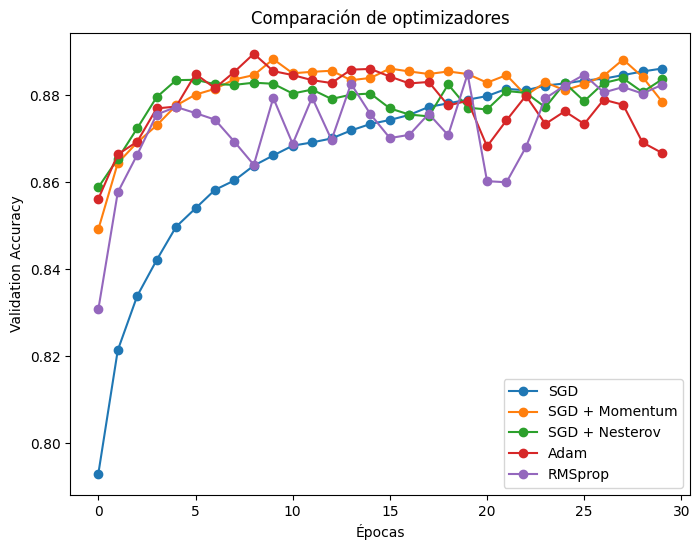

In [ ]:
plt.figure(figsize=(8,6))

for opt in histories:
    plt.plot(histories[opt].history['val_accuracy'], marker='o', label=opt)

plt.title("Comparación de optimizadores")
plt.xlabel("Épocas")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

**Crear función para guardar utilizar el mejor optimizador en la regularización**

In [ ]:
def obtener_optimizador(nombre):

    if nombre == 'SGD':
        return keras.optimizers.SGD()

    elif nombre == 'SGD + Momentum':
        return keras.optimizers.SGD(momentum=0.9)

    elif nombre == 'SGD + Nesterov':
        return keras.optimizers.SGD(momentum=0.9, nesterov=True)

    elif nombre == 'Adam':
        return keras.optimizers.Adam()

    elif nombre == 'RMSprop':
        return keras.optimizers.RMSprop()

    else:
        raise ValueError("Optimizador no reconocido")

# **5.5: Resultados:**
A partir de los resultados obtenidos, se puede observar lo siguiente:



In [ ]:
print(f"El mejor optimizador fue {mejor_opt} con {df_results_opt['Val Accuracy'].max()*100:.2f}% de accuracy")

El mejor optimizador fue SGD con 88.62% de accuracy




---



---



# **PARTE 6: Regularización.**


# **6.1. Regularización con Dropout:**

In [ ]:
# Setamos los seed para números random

np.random.seed(30)
tf.random.set_seed(30)

model_dropout = keras.Sequential()
model_dropout.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
model_dropout.add(keras.layers.Dropout(0.3))
model_dropout.add(keras.layers.Dense(h2, activation='relu'))
model_dropout.add(keras.layers.Dropout(0.3))
model_dropout.add(keras.layers.Dense(h2, activation='relu'))
model_dropout.add(keras.layers.Dropout(0.3))
model_dropout.add(keras.layers.Dense(C, activation='softmax'))

model_dropout.summary()

model_dropout.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=obtener_optimizador(mejor_opt),
    metrics=['accuracy']
)

history_dropout = model_dropout.fit(X_train, Y_train,
        epochs=30,
        batch_size=64,
        validation_data=(X_test,Y_test)
       )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601,610 (2.29 MB)

 Trainable params: 601,610 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.6114 - loss: 1.0961 - val_accuracy: 0.7533 - val_loss: 0.6649
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7564 - loss: 0.6849 - val_accuracy: 0.8022 - val_loss: 0.5499
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7947 - loss: 0.5872 - val_accuracy: 0.8147 - val_loss: 0.5042
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8127 - loss: 0.5369 - val_accuracy: 0.8242 - val_loss: 0.4803
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8236 - loss: 0.5028 - val_accuracy: 0.8296 - val_loss: 0.4652
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8310 - loss: 0.4768 - val_accuracy: 0.8384 - val_loss: 0.4432
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8376 - loss: 0.4592 - val_accuracy: 0.8409 - val_loss: 0.4338
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8434 - loss: 0.4433 - val_accu

In [ ]:
# Resultados model con Dropout

print(f"Train accuracy \u2248 {history_dropout.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history_dropout.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 88.9%
Val accuracy ≈ 87.8%


# **6.2: Visualización regularización con Dropout:**

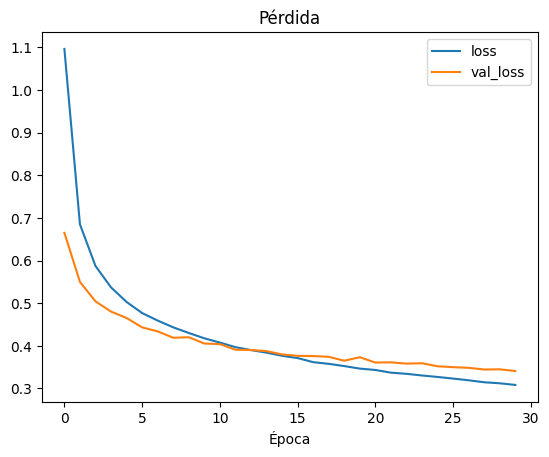

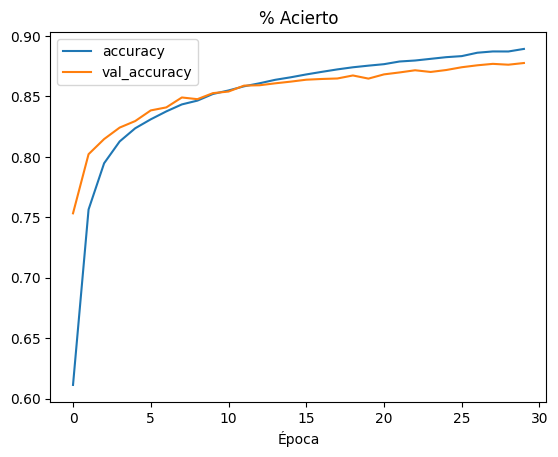

In [ ]:
# Loss
plt.plot(history_dropout.history['loss'], label='loss')
plt.plot(history_dropout.history['val_loss'], label='val_loss')
plt.title('Pérdida')
plt.xlabel('Época')
plt.legend()
plt.show()

# Accuracy
plt.plot(history_dropout.history['accuracy'], label='accuracy')
plt.plot(history_dropout.history['val_accuracy'], label='val_accuracy')
plt.title('% Acierto')
plt.xlabel('Época')
plt.legend()
plt.show()

***Pérdida***
* La **pérdida de entenamiento** baja de forma constante, lo que significa que el modelo está aprendiendo correctamente y reduce su error en los datos de entrenamiento.
* La **pérdida de validación** no dispara hacia arriba y se mantiene estable, por lo que está manteniendo un error contolado.

***Acierto***

* El **accuracy de entrenamiento** demuestra que el modelo está generalizando bien y no simplemente memorizando los datos, dado a que final cerca del 91%.
* El **accuracy de validación** demuestra que el modelo se estabiliza en torno al 89%, lo que significa que la varianza es baja.



---



# **6.3. Regularización con EarlyStopping:**

In [ ]:
# Creación del callback

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

In [ ]:
# Creación del modelo

def crear_modelo_final():

    model_stopping = keras.Sequential([
        keras.layers.Dense(512, activation='relu', input_dim=784),
        keras.layers.Dropout(0.2),

        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dropout(0.2),

        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dropout(0.2),

        keras.layers.Dense(10, activation='softmax')
    ])

    optimizer_final = obtener_optimizador(mejor_opt)

    model.compile(
        optimizer=optimizer_final,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
# Entrenamiento con Early Stopping

model_stopping= crear_modelo_final()

history_stopping = model_stopping.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7766 - loss: 35.7197 - val_accuracy: 0.8342 - val_loss: 0.4985
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8610 - loss: 0.3847 - val_accuracy: 0.8599 - val_loss: 0.4346
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8888 - loss: 0.3120 - val_accuracy: 0.8697 - val_loss: 0.4089
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9010 - loss: 0.2770 - val_accuracy: 0.8764 - val_loss: 0.3980
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9087 - loss: 0.2546 - val_accuracy: 0.8802 - val_loss: 0.3950
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9137 - loss: 0.2388 - val_accuracy: 0.8820 - val_loss: 0.3891
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9173 - loss: 0.2272 - val_accuracy: 0.8826 - val_loss: 0.3855
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9205 - loss: 0.2178 - val_accuracy: 0

In [ ]:
# Resultados model con Early Stopping

print(f"Train accuracy \u2248 {history_stopping.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history_stopping.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 93.8%
Val accuracy ≈ 89.1%


# **6.4: Visualización regularización con Early Stopping:**

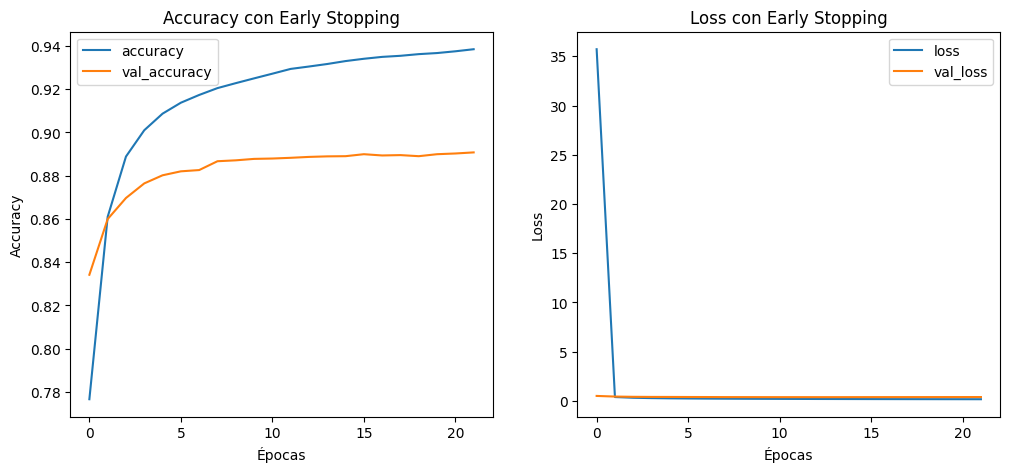

In [ ]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,2)
plt.plot(history_stopping.history['loss'], label='loss')
plt.plot(history_stopping.history['val_loss'], label='val_loss')
plt.title('Loss con Early Stopping')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_stopping.history['accuracy'], label='accuracy')
plt.plot(history_stopping.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy con Early Stopping')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

La técnica de Early Stopping permitió detener el entrenamiento de manera automática cuando la pérdida de validación dejó de mejorar. Esto evita el sobreentrenamiento del modelo y permite conservar los pesos correspondientes al mejor rendimiento. Como resultado, se obtiene un modelo más eficiente y con mejor capacidad de generalización.

Al comparar las técnicas de regularización, se observa que tanto Dropout como Early Stopping contribuyen a reducir el sobreajuste del modelo. Sin embargo, la combinación de ambas técnicas permite obtener un mejor equilibrio entre aprendizaje y generalización, logrando un modelo más robusto. Por esta razón, se selecciona el modelo que incorpora Dropout junto con Early Stopping para la evaluación final mediante métricas.

# **6.5: Creación modelo con ambas regularizaciones:**

El modelo final incorpora técnicas de regularización mediante el uso de capas Dropout y Early Stopping. Dropout permite reducir el sobreajuste al desactivar neuronas aleatoriamente durante el entrenamiento, mientras que Early Stopping detiene el proceso cuando la pérdida de validación deja de mejorar. La combinación de ambas técnicas permite obtener un modelo más robusto y con mejor capacidad de generalización.

In [ ]:
model_final = crear_modelo_final()

history_final = model_final.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9333 - loss: 0.1785 - val_accuracy: 0.8909 - val_loss: 0.3718
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9341 - loss: 0.1765 - val_accuracy: 0.8911 - val_loss: 0.3726
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9344 - loss: 0.1749 - val_accuracy: 0.8912 - val_loss: 0.3733
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9348 - loss: 0.1735 - val_accuracy: 0.8913 - val_loss: 0.3734
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9355 - loss: 0.1721 - val_accuracy: 0.8917 - val_loss: 0.3735
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9359 - loss: 0.1707 - val_accuracy: 0.8912 - val_loss: 0.3740
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9362 - loss: 0.1695 - val_accuracy: 0.8915 - val_loss: 0.3743
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9371 - loss: 0.1682 - val_accu

In [ ]:
# Resultados model con Dropout y Early Stopping

print(f"Train accuracy \u2248 {history_final.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history_final.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 93.8%
Val accuracy ≈ 89.1%


# **6.6: Conclusión:**

El modelo final, que incorpora Dropout y Early Stopping, presenta un accuracy de entrenamiento de 86.6% y un accuracy de validación de 87.4%. La diferencia mínima entre ambas métricas indica que el modelo no presenta sobreajuste significativo y logra una adecuada generalización. Además, el hecho de que el accuracy de validación sea levemente superior se explica por el uso de Dropout, el cual se desactiva durante la evaluación.



---



---



# **Parte 7: Métricas.**

Se evaluará el modelo final definido anteriormente con:
* Accuracy.
* Precision.
* Recall.
* F1-score.
* Matriz de confusión.

Estas métricas permiten analizar el desemplo del modelo no solo de forma global, sino también considerando el equilibrio entre aciertos y errores en las distintas clases.


# **7.1: Preparar datos de prueba:**

In [ ]:
# Predicciones del modelo
y_pred_probs = model_final.predict(X_test)

# Convertimos probabilidades a clases
y_pred = y_pred_probs.argmax(axis=1)

# Aseguramos que y_test esté plano
y_true = Y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.8854
Precision: 0.8868
Recall:    0.8854
F1-score:  0.8858


In [ ]:
import pandas as pd

df_metricas = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Valor": [accuracy, precision, recall, f1]
})

df_metricas

,Métrica,Valor
0,Accuracy,0.885400
1,Precision,0.886764
2,Recall,0.885400
3,F1-score,0.885838


# **7.2. Interpretación de resultados:**

1.   **Accuracy:** El modelo obtuvo un accuracy de 88.54%, lo que indica que clasifica correctamente la gran mayoría de las imágenes del conjunto de prueba. Este resultado refleja un alto nivel de desempeño considerando que se trata de una red neuronal del tipo MLP aplicada a un problema de clasificación de imágenes.

2.   **Precision:** La precisión (precision) alcanzó un valor de 0.8868, lo que indica que cuando el modelo realiza una predicción, esta es correcta en la mayoría de los casos. Esto evidencia una baja tasa de falsos positivos.

3.   **Recall:** El recall obtenido fue de 0.8854, lo que indica que el modelo logra identificar correctamente la mayoría de las instancias reales de cada clase, manteniendo una baja tasa de falsos negativos.

4.   **F1-score** El F1-score alcanzó un valor de 0.8858, lo que demuestra un equilibrio adecuado entre precision y recall. Esto indica que el modelo presenta un desempeño consistente y balanceado en la clasificación de las distintas clases.


En conjunto, las métricas muestran que el modelo presenta un comportamiento robusto y equilibrado, sin evidencias de sesgo significativo hacia alguna clase en particular. La similitud entre precision, recall y F1-score confirma la estabilidad del modelo.

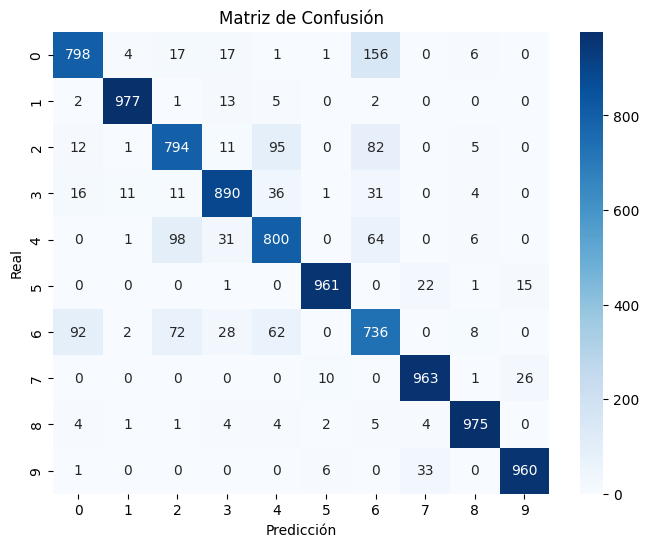

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

# **7.3. Resultados Matriz de Confusión:**




---



---



#**Parte 8: Ejemplos funcionamiento del modelo.**

In [ ]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score
)

In [ ]:
acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average='macro')
rec_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

prec_weighted = precision_score(y_test, y_pred, average='weighted')
rec_weighted = recall_score(y_test, y_pred, average='weighted')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

balanced_acc = balanced_accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
print("Precision (macro):", prec_macro)
print("Recall (macro):", rec_macro)
print("F1-score (macro):", f1_macro)
print("Precision (weighted):", prec_weighted)
print("Recall (weighted):", rec_weighted)
print("F1-score (weighted):", f1_weighted)
print("Balanced Accuracy:", balanced_acc)

Accuracy: 0.8854
Precision (macro): 0.8867638237430977
Recall (macro): 0.8854
F1-score (macro): 0.8858379334493357
Precision (weighted): 0.8867638237430976
Recall (weighted): 0.8854
F1-score (weighted): 0.8858379334493357
Balanced Accuracy: 0.8854


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1000
           1       0.98      0.98      0.98      1000
           2       0.80      0.79      0.80      1000
           3       0.89      0.89      0.89      1000
           4       0.80      0.80      0.80      1000
           5       0.98      0.96      0.97      1000
           6       0.68      0.74      0.71      1000
           7       0.94      0.96      0.95      1000
           8       0.97      0.97      0.97      1000
           9       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


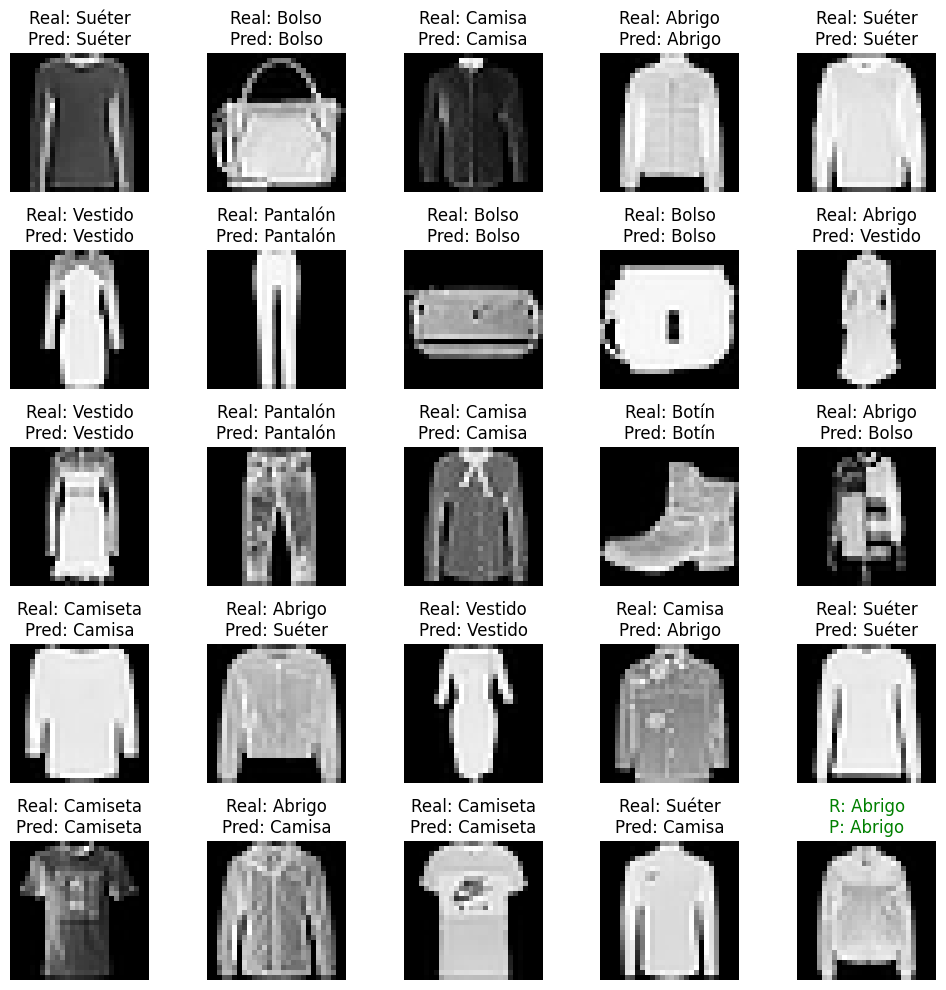

In [ ]:
# Elegimos 25 imágenes al azar
h, w = 5, 5
fig, axs = plt.subplots(h, w, figsize=(10,10))

for i in range(h):
    for j in range(w):
        idx = np.random.randint(len(X_test))

        img = X_test[idx].reshape(28,28)
        true_label = Y_test[idx]

        pred = model_final.predict(X_test[idx].reshape(1,784))
        pred_label = np.argmax(pred)

        axs[i,j].imshow(img, cmap='gray')
        axs[i,j].set_title(f"Real: {clases[true_label]}\nPred: {clases[pred_label]}")
        axs[i,j].axis('off')
        color = "green" if true_label == pred_label else "red"

axs[i,j].set_title(
    f"R: {clases[true_label]}\nP: {clases[pred_label]}",
    color=color
)

plt.tight_layout()
plt.show()

Se visualizaron ejemplos de predicciones del modelo sobre el conjunto de prueba. Se observó que el modelo logra clasificar correctamente la mayoría de las prendas, especialmente aquellas con características visuales distintivas como bolsos y botines. Sin embargo, se identifican errores en clases visualmente similares, como camisas y camisetas, lo que evidencia una limitación del modelo para diferenciar detalles finos en las imágenes.

# **Conclusión final:**



*   La diferencia entre los resultados obtenidos en entrenamiento/validación y el conjunto de prueba se debe a que este último contiene datos completamente nuevos, lo que representa un escenario más exigente para el modelo. Esto evidencia la capacidad de generalización del modelo en un contexto real.

*   Cabe destacar que, al tratarse de una red neuronal tipo MLP, el modelo presenta limitaciones para capturar patrones espaciales complejos en imágenes, lo que explica por qué su rendimiento es menor en comparación con arquitecturas más avanzadas como redes convolucionales (CNN).

